# Tutorial 4, Q3: Titanic data analysis with feature interpretation

In [1]:
# Initial imports
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from scipy import stats
import pandas as pd

Download the dataset from https://biostat.app.vumc.org/wiki/pub/Main/DataSets/titanic3.csv and update the cell below with the path to the dataset csv.

In [2]:
# Download dataset from: https://biostat.app.vumc.org/wiki/pub/Main/DataSets/titanic3.csv
# Update path to dataset here.
dataset_path = "titanic3.csv"

In [3]:
# Read dataset from csv file using pandas and display the data frame
titanic_data = pd.read_csv(dataset_path)
titanic_data

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


With the data loaded, we now preprocess the data by converting some categorical features such as gender, location of embarcation, and passenger class into one-hot encodings (separate feature columns for each class with 0 / 1). We also remove some features that are more difficult to analyze, such as name, and fill missing values in age and fare with the average values. 

In [4]:
# Preprocess the data by converting categorical variables into dummy/indicator variables and concatenate them to the original data frame. 
titanic_data = pd.concat([titanic_data,
                          pd.get_dummies(titanic_data['sex']),
                          pd.get_dummies(titanic_data['embarked'],prefix="embark"),
                          pd.get_dummies(titanic_data['pclass'],prefix="class")], axis=1)# Drop the columns that are not needed for training the model.

In [5]:
# impute the mean of the age and fare columns and fill the missing values with the mean. 
titanic_data["age"] = titanic_data["age"].fillna(titanic_data["age"].mean())
titanic_data["fare"] = titanic_data["fare"].fillna(titanic_data["fare"].mean())

In [6]:
# Drop the columns that are not needed for training the model.
titanic_data = titanic_data.drop(['name','ticket','cabin','boat','body','home.dest','sex','embarked','pclass'], axis=1)
titanic_data.to_csv('titanic_cleaned.csv', index=False)
titanic_data

,survived,age,sibsp,parch,fare,female,male,embark_C,embark_Q,embark_S,class_1,class_2,class_3
0,1,29.000000,0,0,211.3375,True,False,False,False,True,True,False,False
1,1,0.920000,1,2,151.5500,False,True,False,False,True,True,False,False
2,0,2.000000,1,2,151.5500,True,False,False,False,True,True,False,False
3,0,30.000000,1,2,151.5500,False,True,False,False,True,True,False,False
4,0,25.000000,1,2,151.5500,True,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,0,14.500000,1,0,14.4542,True,False,True,False,False,False,False,True
1305,0,29.881138,1,0,14.4542,True,False,True,False,False,False,False,True
1306,0,26.500000,0,0,7.2250,False,True,True,False,False,False,False,True
1307,0,27.000000,0,0,7.2250,False,True,True,False,False,False,False,True


After processing, the features we have are:

* Age - Passenger Age
* Sibsp - Number of Siblings / Spouses Aboard
* Parch - Number of Parents / Children Aboard
* Fare - Fare Amount Paid in British Pounds
* Female - Binary variable indicating whether passenger is female
* Male - Binary variable indicating whether passenger is male
* EmbarkC - Binary variable indicating whether passenger embarked at Cherbourg
* EmbarkQ - Binary variable indicating whether passenger embarked at Queenstown
* EmbarkS - Binary variable indicating whether passenger embarked at Southampton
* Class1 - Binary variable indicating whether passenger was in first class
* Class2 - Binary variable indicating whether passenger was in second class
* Class3 - Binary variable indicating whether passenger was in third class

(Reference: http://campus.lakeforest.edu/frank/FILES/MLFfiles/Bio150/Titanic/TitanicMETA.pdf)

We now convert the data to numpy arrays and separate the training and test sets.

In [7]:
# Set random seed for reproducibility.
np.random.seed(131254)

# Convert features and labels to numpy arrays.
labels = titanic_data["survived"].to_numpy()
titanic_data = titanic_data.drop(['survived'], axis=1)
feature_names = list(titanic_data.columns)
data = titanic_data.to_numpy()
data, labels

(array([[29.0, 0, 0, ..., True, False, False],
        [0.92, 1, 2, ..., True, False, False],
        [2.0, 1, 2, ..., True, False, False],
        ...,
        [26.5, 0, 0, ..., False, False, True],
        [27.0, 0, 0, ..., False, False, True],
        [29.0, 0, 0, ..., False, False, True]],
       shape=(1309, 12), dtype=object),
 array([1, 1, 0, ..., 0, 0, 0], shape=(1309,)))

In [8]:
# Separate training and test sets using 
train_indices = np.random.choice(len(labels), int(0.7*len(labels)), replace=False)
test_indices = list(set(range(len(labels))) - set(train_indices))
train_features = np.array(data[train_indices], dtype=float)
train_labels = labels[train_indices]
test_features = np.array(data[test_indices], dtype=float)
test_labels = labels[test_indices]

We are now ready to define the neural network architecture we will use for the task. We have defined a simple architecture using 2 hidden layers, the first with 12 hidden units and the second with 8 hidden units, each with Sigmoid non-linearity. The final layer performs a softmax operation and has 2 units, corresponding to the outputs of either survived (1) or not survived (0).

In [9]:
import torch
import torch.nn as nn
torch.manual_seed(1)  # Set seed for reproducibility.

class TitanicNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(12, 12)
        self.sigmoid1 = nn.Sigmoid()
        self.linear2 = nn.Linear(12, 8)
        self.sigmoid2 = nn.Sigmoid()
        self.linear3 = nn.Linear(8, 2)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        lin1_out = self.linear1(x)
        sigmoid_out1 = self.sigmoid1(lin1_out)
        sigmoid_out2 = self.sigmoid2(self.linear2(sigmoid_out1))
        return self.softmax(self.linear3(sigmoid_out2))

We can either use a pretrained model or train the network using the training data for 200 epochs. Note that the results of later steps may not match if retraining. The pretrained model can be downloaded here: https://github.com/pytorch/captum/blob/master/tutorials/models/titanic_model.pt

In [10]:
net = TitanicNNModel()
USE_PRETRAINED_MODEL = False

if USE_PRETRAINED_MODEL:
    net.load_state_dict(torch.load('models/titanic_model.pt'))
    print("Model Loaded!")
    input_tensor = torch.from_numpy(train_features).type(torch.FloatTensor)
    label_tensor = torch.from_numpy(train_labels)
else:
    criterion = nn.CrossEntropyLoss()
    num_epochs = 200

    optimizer = torch.optim.Adam(net.parameters(), lr=0.1)
    input_tensor = torch.from_numpy(train_features).type(torch.FloatTensor)
    label_tensor = torch.from_numpy(train_labels)
    for epoch in range(num_epochs):    
        output = net(input_tensor)
        loss = criterion(output, label_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 20 == 0:
            print ('Epoch {}/{} => Loss: {:.2f}'.format(epoch+1, num_epochs, loss.item()))

#    torch.save(net.state_dict(), 'models/titanic_model.pt')

Epoch 1/200 => Loss: 0.70
Epoch 21/200 => Loss: 0.55
Epoch 41/200 => Loss: 0.50
Epoch 61/200 => Loss: 0.49
Epoch 81/200 => Loss: 0.49
Epoch 101/200 => Loss: 0.48
Epoch 121/200 => Loss: 0.48
Epoch 141/200 => Loss: 0.48
Epoch 161/200 => Loss: 0.47
Epoch 181/200 => Loss: 0.47


We can now evaluate the training and test accuracies of our model.

In [11]:
out_probs = net(input_tensor).detach().numpy()
out_classes = np.argmax(out_probs, axis=1)
print("Train Accuracy:", sum(out_classes == train_labels) / len(train_labels))

Train Accuracy: 0.8471615720524017


In [12]:
test_input_tensor = torch.from_numpy(test_features).type(torch.FloatTensor)
out_probs = net(test_input_tensor).detach().numpy()
out_classes = np.argmax(out_probs, axis=1)
print("Test Accuracy:", sum(out_classes == test_labels) / len(test_labels))

Test Accuracy: 0.816793893129771


Beyond just considering the accuracy of the classifier, there are many important questions to understand how the model is working and it's decision, which is the purpose of Captum, to help make neural networks in PyTorch more interpretable.

To apply integrated gradients, we first create an IntegratedGradients object, providing the model object.

In [13]:
from captum.attr import IntegratedGradients

ig = IntegratedGradients(net)

To compute the integrated gradients, we use the attribute method of the IntegratedGradients object. The method takes tensor(s) of input examples (matching the forward function of the model), and returns the input attributions for the given examples. For a network with multiple outputs, a target index must also be provided, defining the index of the output for which gradients are computed. For this example, we provide target = 1, corresponding to survival. 

The input tensor provided should require grad, so we call requires\_grad\_ on the tensor. The attribute method also takes a baseline, which is the starting point from which gradients are integrated. The default value is just the 0 tensor, which is a reasonable baseline / default for this task. 

The returned values of the attribute method are the attributions, which match the size of the given inputs, and delta, which approximates the error between the approximated integral and true integral.

In [14]:
test_input_tensor.requires_grad_()
attr, delta = ig.attribute(test_input_tensor, target=1, return_convergence_delta=True)
attr = attr.detach().numpy()
np.shape(attr)

(393, 12)

To understand these attributions, we can first average them across all the inputs and print / visualize the average attribution for each feature.

Average Feature Importances
age :  -0.397
sibsp :  -0.063
parch :  -0.012
fare :  0.074
female :  0.116
male :  -0.432
embark_C :  0.112
embark_Q :  0.020
embark_S :  -0.087
class_1 :  0.075
class_2 :  0.016
class_3 :  -0.144


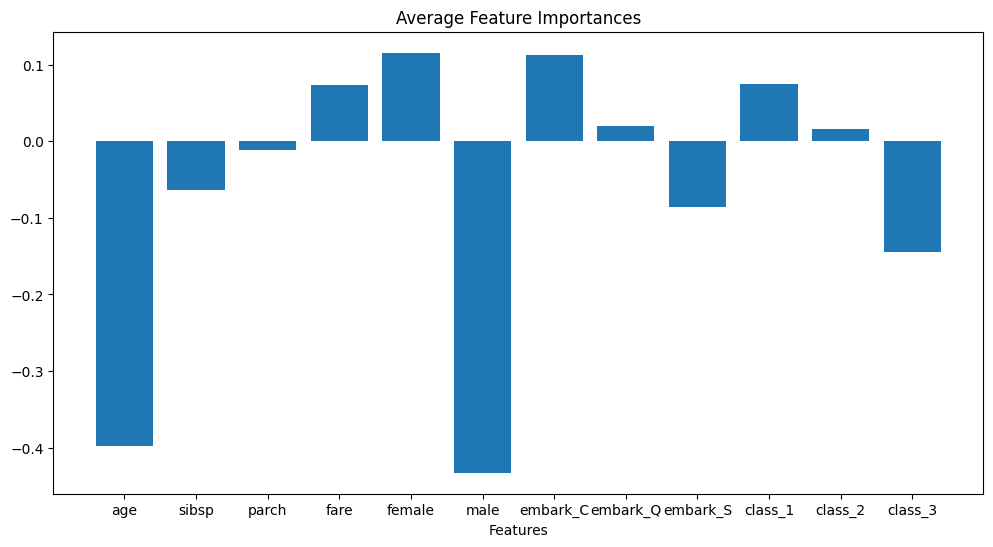

In [15]:
# Helper method to print importances and visualize distribution
def visualize_importances(feature_names, importances, title="Average Feature Importances", plot=True, axis_title="Features"):
    print(title)
    for i in range(len(feature_names)):
        print(feature_names[i], ": ", '%.3f'%(importances[i]))
    x_pos = (np.arange(len(feature_names)))
    if plot:
        plt.figure(figsize=(12,6))
        plt.bar(x_pos, importances, align='center')
        plt.xticks(x_pos, feature_names, wrap=True)
        plt.xlabel(axis_title)
        plt.title(title)
visualize_importances(feature_names, np.mean(attr, axis=0))

From the feature attribution information, we obtain some interesting insights regarding the importance of various features. We see that the strongest features appear to be age and being male, which are negatively correlated with survival. Embarking at Queenstown and the number of parents / children appear to be less important features generally.

An important thing to note is that the average attributions over the test set don't necessarilly capture all the information regarding feature importances. We should also look at the distribution of attributions for each feature. It is possible that features have very different attributions for different examples in the dataset. 

For instance, we can visualize the distribution of attributions for sibsp, the number of siblings / spouses.

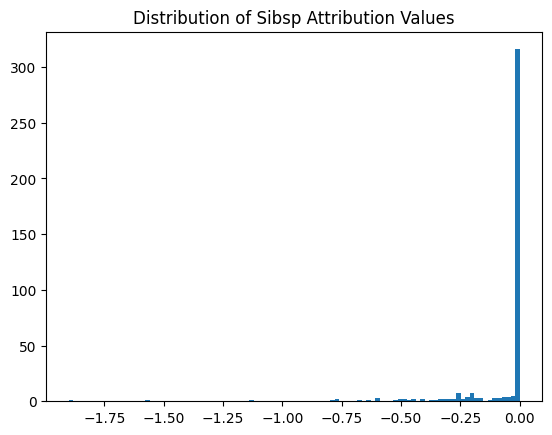

In [16]:
plt.hist(attr[:,1], 100);
plt.title("Distribution of Sibsp Attribution Values");

We note that a vast majority of the examples have an attribution value of 0 for sibsp, which likely corresponds to having a value of 0 for the feature (IntegratedGradients would provide an attribution of 0 when the feature value matches the baseline of 0). More significantly, we see that although the average seems smaller in magnitude in the plot above, there are a small number of examples with extremely negative attributions for this feature.

To better understand this, we can bucket the examples by the value of the sibsp feature and plot the average attribution for the feature. In the plot below, the size of the dot is proportional to the number of examples with that value.

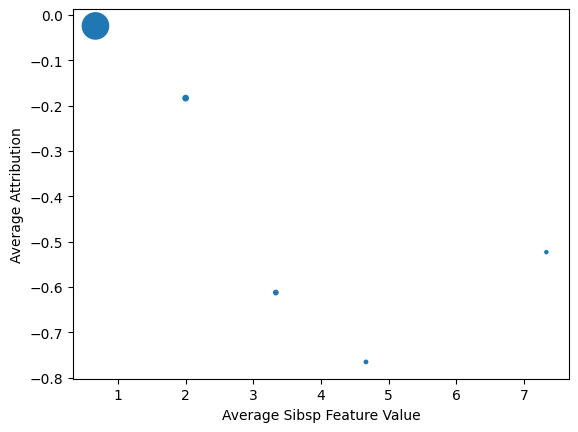

In [17]:
bin_means, bin_edges, _ = stats.binned_statistic(test_features[:,1], attr[:,1], statistic='mean', bins=6)
bin_count, _, _ = stats.binned_statistic(test_features[:,1], attr[:,1], statistic='count', bins=6)

bin_width = (bin_edges[1] - bin_edges[0])
bin_centers = bin_edges[1:] - bin_width/2
plt.scatter(bin_centers, bin_means, s=bin_count)
plt.xlabel("Average Sibsp Feature Value");
plt.ylabel("Average Attribution");


We see that the larger magnitude attributions correspond to the examples with larger Sibsp feature values, suggesting that the feature has a larger impact on prediction for these examples. Since there are substantially fewer of these examples (compared to those with a feature value of 0), the average attribution does not completely capture this effect.